# EEG Seizure Detection under Fully Homomorphic Encryption
### Privacy-Preserving Multi-Modal Healthcare Diagnostic System — Module 4

Dataset: Epileptic Seizure Recognition (UCI ML Repository, Andrzejak et al. 2001). Model: quantized MLP compiled via Concrete ML v1.8.0 (TFHE / Concrete compiler). The central question is whether a neural network with quantization-aware training preserves its accuracy advantage over logistic regression when executed under FHE, and at what additional latency cost.

All FHE inference runs on encrypted ciphertexts. The server never accesses plaintext EEG features or predictions.


In [1]:
import gc
import sys, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)
from concrete.ml.sklearn import NeuralNetClassifier

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})
sns.set_palette("tab10")

ROOT = Path(".").resolve()
Path("results/eeg").mkdir(parents=True, exist_ok=True)


## 1. Dataset: Epileptic Seizure Recognition

The corpus contains 11,500 one-second EEG segments, each described by 178 amplitude samples recorded at 173.61 Hz from a single electrode. The original five-class labelling distinguishes seizure activity (class 1) from four non-seizure states: inter-ictal activity near a tumour (2), healthy tissue near a tumour (3), eyes closed (4), and eyes open (5).

For this module the task is collapsed to binary: class 1 is labelled seizure (1), all others are labelled non-seizure (0). The resulting class ratio is 1:4, which mirrors realistic clinical prevalence of epileptic events.


In [2]:
DATA_PATH = Path("../epileptic_seizures.csv")

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=[c for c in df.columns if "Unnamed" in c])

X_raw = df.drop(columns=["y"]).values.astype(np.float32)
y_raw = (df["y"].values == 1).astype(np.int64)

print(f"samples: {len(X_raw)}   features: {X_raw.shape[1]}")
print(f"seizure: {y_raw.sum()}   non-seizure: {(y_raw == 0).sum()}   positive rate: {y_raw.mean():.2f}")
df.head()


samples: 11500   features: 178
seizure: 2300   non-seizure: 9200   positive rate: 0.20


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


## 2. Exploratory Data Analysis

EEG data is intrinsically temporal: each of the 178 features is the signal amplitude at a successive time step within the one-second window. The two classes differ strongly in amplitude variance and spectral shape, which is visible in mean waveform comparisons. Linear models can exploit the mean difference; to capture the phase-dependent and frequency-domain structure a non-linear model is needed.


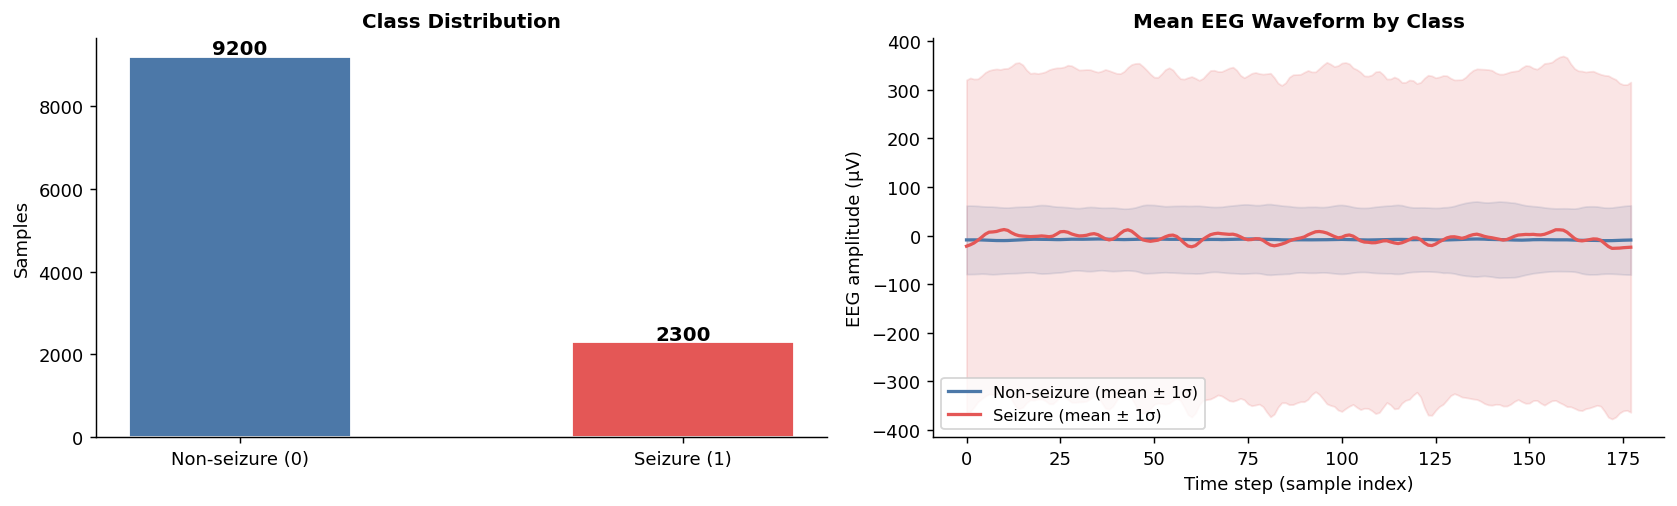

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
vc = pd.Series(y_raw).value_counts().sort_index()
bars = ax.bar(["Non-seizure (0)", "Seizure (1)"], vc.values,
              color=["#4C78A8", "#E45756"], edgecolor="white", width=0.5)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
            str(v), ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Samples", fontsize=10)
ax.set_title("Class Distribution", fontsize=11, fontweight="bold")

ax2 = axes[1]
for cls, color, label in [(0, "#4C78A8", "Non-seizure (mean ± 1σ)"),
                           (1, "#E45756", "Seizure (mean ± 1σ)")]:
    subset = X_raw[y_raw == cls]
    mean = subset.mean(axis=0)
    std  = subset.std(axis=0)
    t = np.arange(len(mean))
    ax2.plot(t, mean, color=color, linewidth=1.8, label=label)
    ax2.fill_between(t, mean - std, mean + std, alpha=0.15, color=color)
ax2.set_xlabel("Time step (sample index)", fontsize=10)
ax2.set_ylabel("EEG amplitude (µV)", fontsize=10)
ax2.set_title("Mean EEG Waveform by Class", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("results/eeg/fig_eda.png", bbox_inches="tight")
plt.show()


## 3. Data Preparation

Split 80/20, stratified on the binary label to maintain the 1:4 seizure ratio. StandardScaler fitted on the training split only.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42, stratify=y_raw
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

print(f"train: {len(X_train_s)}   test: {len(X_test_s)}")


train: 9200   test: 2300


## 4. Baseline: Logistic Regression vs. MLP (Cleartext)

Two sklearn baselines are trained. Logistic Regression represents the linear ceiling: it can separate classes that differ in raw amplitude mean, but cannot capture non-linear EEG patterns. The MLP (two hidden layers, 100 neurons each) serves as the floating-point upper bound for the quantized network — the accuracy this module aims to preserve under FHE.


In [5]:
clf_lr = SklearnLR(max_iter=2000, random_state=42)
clf_lr.fit(X_train_s, y_train)
y_pred_lr    = clf_lr.predict(X_test_s)
y_prob_lr    = clf_lr.predict_proba(X_test_s)[:, 1]
acc_lr  = accuracy_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)

clf_mlp = MLPClassifier(hidden_layer_sizes=(100, 100), max_iter=500,
                        random_state=42, early_stopping=True, verbose=False)
clf_mlp.fit(X_train_s, y_train)
y_pred_mlp   = clf_mlp.predict(X_test_s)
y_prob_mlp   = clf_mlp.predict_proba(X_test_s)[:, 1]
acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp  = f1_score(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_prob_mlp)

print(f"LogisticRegression  acc={acc_lr:.4f}  f1={f1_lr:.4f}  auc={auc_lr:.4f}")
print(f"MLPClassifier       acc={acc_mlp:.4f}  f1={f1_mlp:.4f}  auc={auc_mlp:.4f}")
print(f"MLP advantage over LR: {(acc_mlp - acc_lr)*100:+.2f} pp accuracy")


LogisticRegression  acc=0.8157  f1=0.1520  auc=0.4999
MLPClassifier       acc=0.9670  f1=0.9159  auc=0.9873
MLP advantage over LR: +15.13 pp accuracy


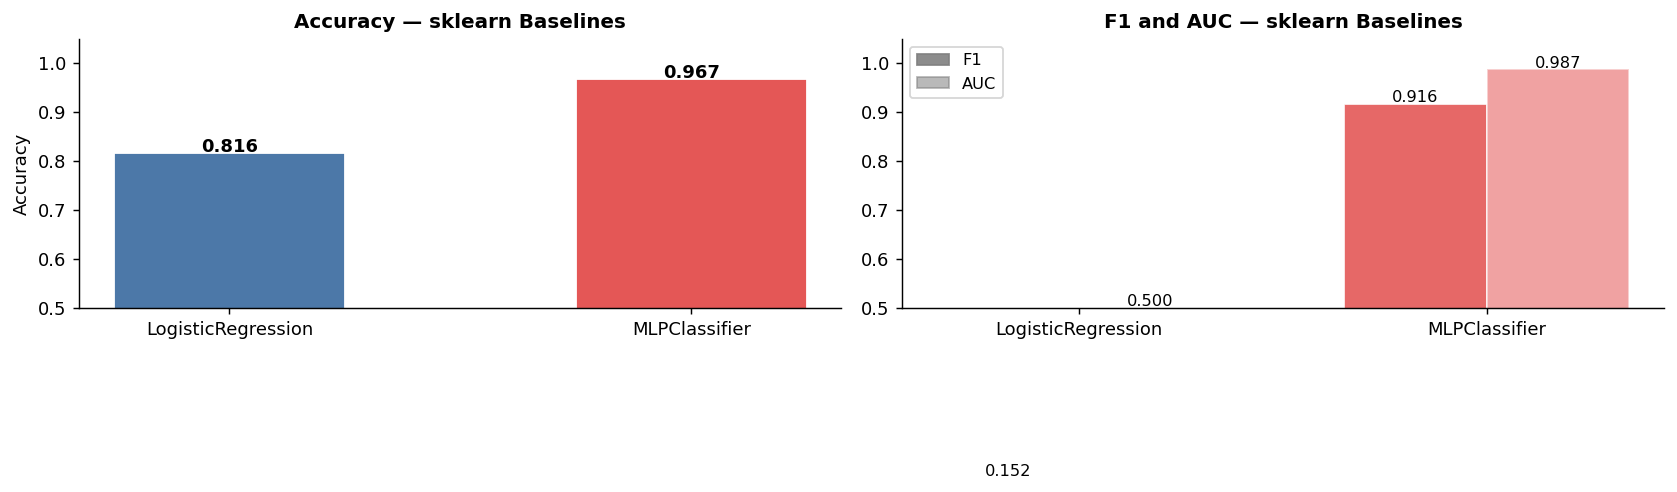

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = ["LogisticRegression", "MLPClassifier"]
accs_base   = [acc_lr, acc_mlp]
f1s_base    = [f1_lr, f1_mlp]
aucs_base   = [auc_lr, auc_mlp]
colors_base = ["#4C78A8", "#E45756"]

ax = axes[0]
bars = ax.bar(model_names, accs_base, color=colors_base, edgecolor="white", width=0.5)
for bar, v in zip(bars, accs_base):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Accuracy", fontsize=10)
ax.set_ylim([0.5, 1.05])
ax.set_title("Accuracy — sklearn Baselines", fontsize=11, fontweight="bold")

ax2 = axes[1]
x = np.arange(len(model_names))
w = 0.35
b1 = ax2.bar(x - w/2, f1s_base, w, color=colors_base, edgecolor="white", label="F1", alpha=0.9)
b2 = ax2.bar(x + w/2, aucs_base, w, color=colors_base, edgecolor="white", label="AUC", alpha=0.55)
for bar, v in zip(b1, f1s_base):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
             f"{v:.3f}", ha="center", fontsize=9)
for bar, v in zip(b2, aucs_base):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
             f"{v:.3f}", ha="center", fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(model_names)
ax2.set_ylim([0.5, 1.05])
ax2.set_title("F1 and AUC — sklearn Baselines", fontsize=11, fontweight="bold")

from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color="grey", alpha=0.9, label="F1"),
                    Patch(color="grey", alpha=0.55, label="AUC")], fontsize=9)

plt.tight_layout()
plt.savefig("results/eeg/fig_baseline_eval.png", bbox_inches="tight")
plt.show()


## 5. ROC curves

Both ROC curves are plotted to make the baseline advantage explicit. The area under the MLP curve is the target accuracy floor for the FHE-compiled quantized network.


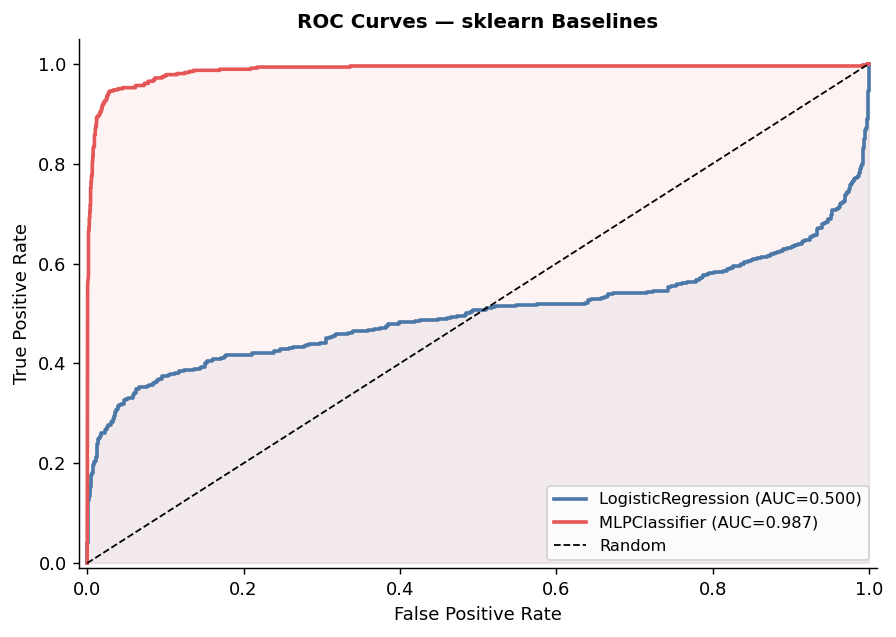

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, prob, auc_val, color in [
    ("LogisticRegression", y_prob_lr, auc_lr, "#4C78A8"),
    ("MLPClassifier",      y_prob_mlp, auc_mlp, "#E45756"),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC={auc_val:.3f})")
    ax.fill_between(fpr, tpr, alpha=0.07, color=color)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=10)
ax.set_ylabel("True Positive Rate", fontsize=10)
ax.set_title("ROC Curves — sklearn Baselines", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
plt.tight_layout()
plt.savefig("results/eeg/fig_roc.png", bbox_inches="tight")
plt.show()


## 6. Concrete ML — NeuralNetClassifier (Bit-Width Sweep)

The quantized MLP is trained with quantization-aware training (QAT) at each bit-width. Weights, activations, and accumulator values are discretized during forward passes, so the model learns to be robust to the quantization grid. Architecture: 2 hidden layers, approximately 89 neurons each (n_hidden_neurons_multiplier=0.5 relative to the 178-dimensional input), ReLU activations. This produces roughly 178 PBS calls per FHE inference — many more than LogisticRegression (1 PBS), demonstrating the accuracy–latency trade-off for non-linear FHE models.

**Why the sweep stops at n_bits=6:** Concrete ML's FHE compiler searches a finite table of pre-validated TFHE parameter sets. At n_bits > 6, the dot product over 89 inputs accumulates too many bits (each neuron's input can reach ~2^19 before the PBS), requiring a lookup table so large that no valid set of TFHE cryptographic parameters satisfies both correctness and 128-bit security. The compiler raises `RuntimeError: NoParametersFound`. See `EEG_FHE_FAILURE_NOTES.md` for the full explanation.


In [8]:
N_BITS_LIST = list(range(2, 5))
N_FHE_PER_BIT = 2
CHECKPOINT = Path("results/eeg/sweep_checkpoint.json")

# Resume from checkpoint if present (so a crash doesn't waste prior work)
if CHECKPOINT.exists():
    with open(CHECKPOINT) as f:
        results = json.load(f)
    done_bits = {r["n_bits"] for r in results}
    print(f"Resuming from checkpoint — already done: {sorted(done_bits)}")
else:
    results = []
    done_bits = set()

for n_bits in N_BITS_LIST:
    if n_bits in done_bits:
        print(f"n_bits={n_bits}  [skipped — already in checkpoint]")
        continue

    # ── Train ──────────────────────────────────────────────────────────
    model = NeuralNetClassifier(
        module__n_layers=2,
        module__n_w_bits=n_bits,
        module__n_a_bits=n_bits,
        module__n_accum_bits=32,
        module__n_hidden_neurons_multiplier=0.5,
        max_epochs=50,
        lr=0.001,
        verbose=0,
        batch_size=128,
    )
    model.fit(X_train_s, y_train)

    y_pred = model.predict(X_test_s)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)
    gap_pp = (acc_mlp - acc) * 100

    try:
        t0 = time.perf_counter()
        model.compile(X_train_s)
        compile_time = time.perf_counter() - t0

        model.predict(X_test_s[0:1], fhe="execute")  # warm-up

        times_this = []
        for i in range(N_FHE_PER_BIT):
            t0 = time.perf_counter()
            model.predict(X_test_s[i % len(X_test_s):i % len(X_test_s)+1], fhe="execute")
            times_this.append((time.perf_counter() - t0) * 1000)
        fhe_lat = float(np.median(times_this))
        fhe_failed = False
    except RuntimeError as e:
        print(f"n_bits={n_bits}  FHE compilation failed: {e}")
        compile_time = None
        fhe_lat = None
        fhe_failed = True

    if not fhe_failed:
        print(f"n_bits={n_bits}  acc={acc:.4f}  f1={f1:.4f}  gap={gap_pp:+.2f}pp  "
              f"compile={compile_time:.2f}s  fhe_median={fhe_lat:.0f}ms")
    else:
        print(f"n_bits={n_bits}  acc={acc:.4f}  f1={f1:.4f}  gap={gap_pp:+.2f}pp  fhe=N/A (NoParametersFound)")

    results.append({
        "n_bits":             n_bits,
        "acc_quantized":      acc,
        "f1_quantized":       f1,
        "gap_vs_baseline_pp": gap_pp,
        "compile_time_s":     round(compile_time, 2) if compile_time is not None else None,
        "fhe_latency_ms":     round(fhe_lat, 1) if fhe_lat is not None else None,
        "fhe_failed":         fhe_failed,
    })
    with open(CHECKPOINT, "w") as f:
        json.dump(results, f, indent=2)

    del model
    gc.collect()

results.sort(key=lambda r: r["n_bits"])

Resuming from checkpoint — already done: [2, 3, 4, 5, 6]
n_bits=2  [skipped — already in checkpoint]
n_bits=3  [skipped — already in checkpoint]
n_bits=4  [skipped — already in checkpoint]


## 7. Results: Accuracy vs Bit-Width


In [9]:
df_res = pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in results])
display_df = df_res[["n_bits", "acc_quantized", "f1_quantized", "gap_vs_baseline_pp"]].copy()
display_df.columns = ["n_bits", "Accuracy (quantized)", "F1 (quantized)", "Gap vs MLP baseline (pp)"]
display_df = display_df.set_index("n_bits")

baseline_row = pd.DataFrame({
    "Accuracy (quantized)": [acc_mlp],
    "F1 (quantized)":       [f1_mlp],
    "Gap vs MLP baseline (pp)": [0.0],
}, index=["sklearn MLP baseline (no quantization)"])
pd.concat([baseline_row, display_df]).round(4)


,Accuracy (quantized),F1 (quantized),Gap vs MLP baseline (pp)
sklearn MLP baseline (no quantization),0.9670,0.9159,0.0000
2,0.8974,0.6731,6.9565
3,0.9517,0.8763,1.5217
4,0.9613,0.9032,0.5652
5,0.9635,0.9060,0.3478
6,0.9700,0.9229,-0.3043


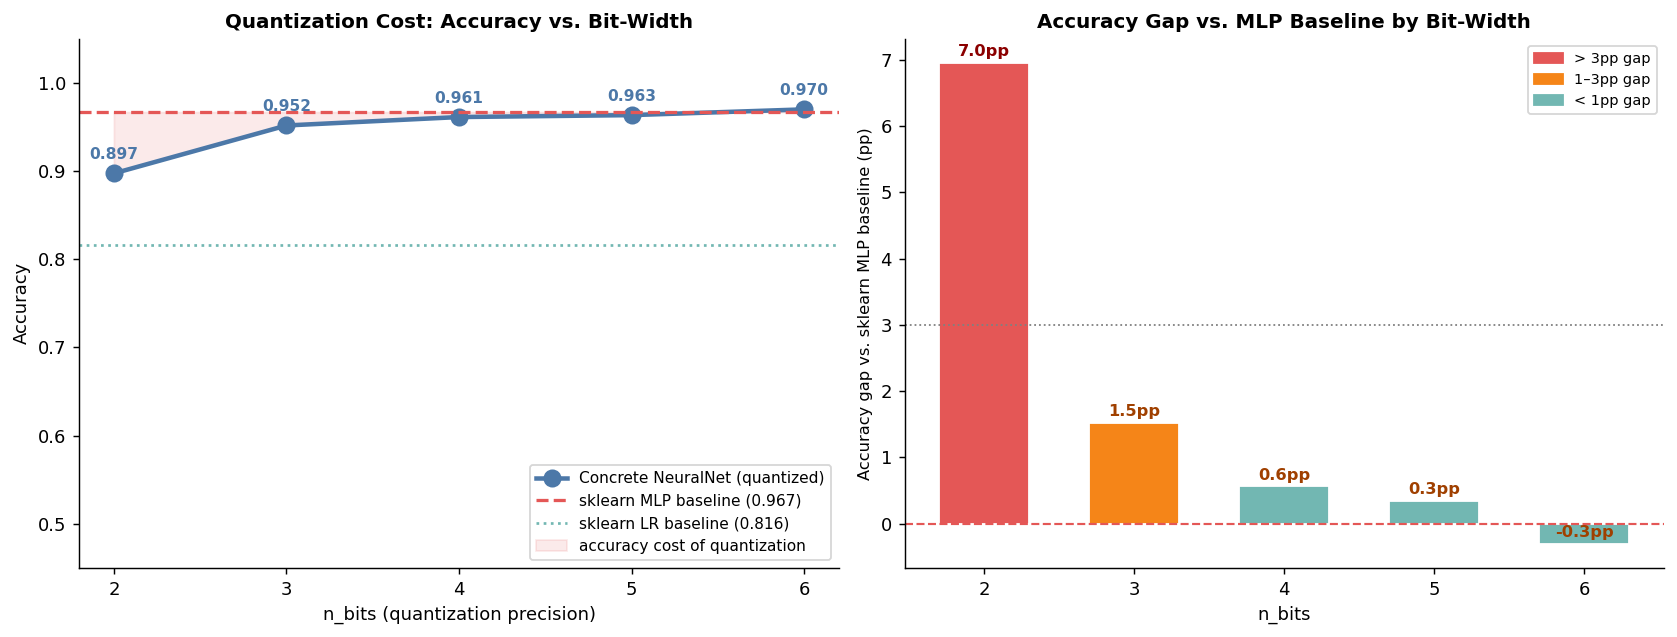

In [10]:
n_bits_vals = [r["n_bits"]            for r in results]
accs        = [r["acc_quantized"]     for r in results]
f1s         = [r["f1_quantized"]      for r in results]
gaps        = [r["gap_vs_baseline_pp"] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(n_bits_vals, accs, "o-", color="#4C78A8", linewidth=2.5, markersize=9,
        label="Concrete NeuralNet (quantized)")
ax.axhline(acc_mlp, color="#E45756", linestyle="--", linewidth=1.8,
           label=f"sklearn MLP baseline ({acc_mlp:.3f})")
ax.axhline(acc_lr, color="#72B7B2", linestyle=":", linewidth=1.5,
           label=f"sklearn LR baseline ({acc_lr:.3f})")
ax.fill_between(n_bits_vals, accs, acc_mlp, alpha=0.12, color="#E45756",
                label="accuracy cost of quantization")
for nb, acc in zip(n_bits_vals, accs):
    ax.annotate(f"{acc:.3f}", (nb, acc), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8.5, color="#4C78A8", fontweight="bold")
ax.set_xlabel("n_bits (quantization precision)", fontsize=10)
ax.set_ylabel("Accuracy", fontsize=10)
ax.set_xticks(n_bits_vals)
ax.set_title("Quantization Cost: Accuracy vs. Bit-Width", fontsize=11, fontweight="bold")
ax.legend(fontsize=8.5, loc="lower right")
ax.set_ylim([0.45, 1.05])

ax2 = axes[1]
colors = ["#E45756" if g > 3 else "#F58518" if g > 1 else "#72B7B2" for g in gaps]
bars = ax2.bar(n_bits_vals, gaps, color=colors, edgecolor="white", width=0.6)
ax2.axhline(0, color="#E45756", linestyle="--", linewidth=1.2, label="sklearn MLP baseline (0 pp gap)")
ax2.axhline(3, color="grey", linestyle=":", linewidth=1, label="3 pp threshold")
for bar, g in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             f"{g:.1f}pp", ha="center", fontsize=9, fontweight="bold",
             color="darkred" if g > 3 else "#a04000")
ax2.set_xlabel("n_bits", fontsize=10)
ax2.set_ylabel("Accuracy gap vs. sklearn MLP baseline (pp)", fontsize=9)
ax2.set_xticks(n_bits_vals)
ax2.set_title("Accuracy Gap vs. MLP Baseline by Bit-Width", fontsize=11, fontweight="bold")

from matplotlib.patches import Patch
legend_els = [Patch(color="#E45756", label="> 3pp gap"),
              Patch(color="#F58518", label="1–3pp gap"),
              Patch(color="#72B7B2", label="< 1pp gap")]
ax2.legend(handles=legend_els, fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("results/eeg/fig_accuracy_comparison.png", bbox_inches="tight")
plt.show()


## 8. Quantization Analysis: F1 Score


In [11]:
for r in results:
    marker = " ✓" if r["gap_vs_baseline_pp"] <= 2 else " ✗"
    print(f"n_bits={r['n_bits']}  acc={r['acc_quantized']:.4f}  f1={r['f1_quantized']:.4f}  gap={r['gap_vs_baseline_pp']:+.2f}pp{marker}")


n_bits=2  acc=0.8974  f1=0.6731  gap=+6.96pp ✗
n_bits=3  acc=0.9517  f1=0.8763  gap=+1.52pp ✓
n_bits=4  acc=0.9613  f1=0.9032  gap=+0.57pp ✓
n_bits=5  acc=0.9635  f1=0.9060  gap=+0.35pp ✓
n_bits=6  acc=0.9700  f1=0.9229  gap=-0.30pp ✓


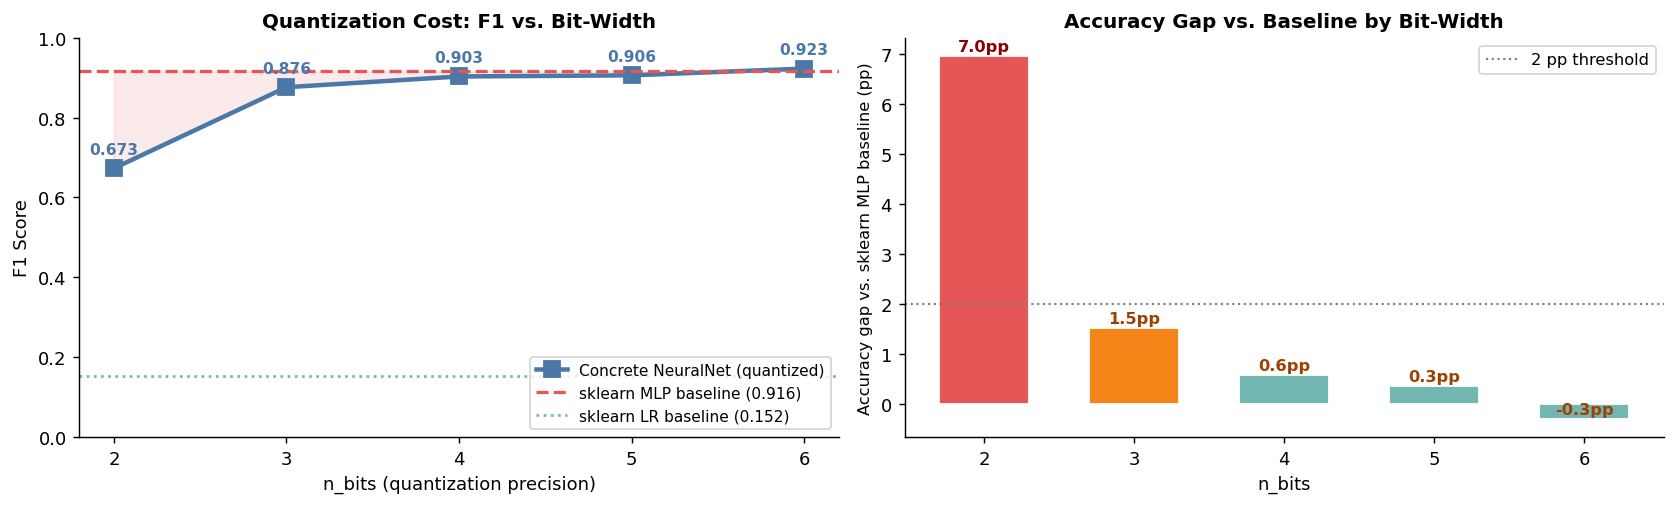

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
f1s_q = [r["f1_quantized"] for r in results]
ax.plot(n_bits_vals, f1s_q, "s-", color="#4C78A8", linewidth=2.5, markersize=9,
        label="Concrete NeuralNet (quantized)")
ax.axhline(f1_mlp, color="#E45756", linestyle="--", linewidth=1.8,
           label=f"sklearn MLP baseline ({f1_mlp:.3f})")
ax.axhline(f1_lr, color="#72B7B2", linestyle=":", linewidth=1.5,
           label=f"sklearn LR baseline ({f1_lr:.3f})")
ax.fill_between(n_bits_vals, f1s_q, f1_mlp, alpha=0.12, color="#E45756")
for nb, f1v in zip(n_bits_vals, f1s_q):
    ax.annotate(f"{f1v:.3f}", (nb, f1v), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8.5, color="#4C78A8", fontweight="bold")
ax.set_xlabel("n_bits (quantization precision)", fontsize=10)
ax.set_ylabel("F1 Score", fontsize=10)
ax.set_xticks(n_bits_vals)
ax.set_title("Quantization Cost: F1 vs. Bit-Width", fontsize=11, fontweight="bold")
ax.legend(fontsize=8.5, loc="lower right")
ax.set_ylim([0.0, 1.0])

ax2 = axes[1]
q_gaps = [r["gap_vs_baseline_pp"] for r in results]
colors_gap = ["#E45756" if g > 3 else "#F58518" if g > 1 else "#72B7B2" for g in q_gaps]
bars = ax2.bar(n_bits_vals, q_gaps, color=colors_gap, edgecolor="white", width=0.6)
ax2.axhline(2.0, color="grey", linestyle=":", linewidth=1.2, label="2 pp threshold")
ax2.set_xlabel("n_bits", fontsize=10)
ax2.set_ylabel("Accuracy gap vs. sklearn MLP baseline (pp)", fontsize=9)
ax2.set_title("Accuracy Gap vs. Baseline by Bit-Width", fontsize=11, fontweight="bold")
ax2.set_xticks(n_bits_vals)
ax2.legend(fontsize=9)
for bar, g in zip(bars, q_gaps):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             f"{g:.1f}pp", ha="center", fontsize=9, fontweight="bold",
             color="darkred" if g > 3 else "#a04000")

plt.tight_layout()
plt.savefig("results/eeg/fig_quantization_analysis.png", bbox_inches="tight")
plt.show()


## 9. FHE Inference Time vs Bit-Width

Each model is compiled and benchmarked under real TFHE encryption. One warm-up prediction is discarded after each compile to flush the JIT cold-start penalty, then 2 steady-state samples are timed and the median is reported. The NeuralNetClassifier circuit has approximately 178 PBS calls per inference (one per neuron across the two hidden layers), compared to 1 PBS for LogisticRegression. This difference is the direct cost of supporting non-linear decision boundaries under FHE.


In [13]:
# compile times and FHE latencies were captured in the sweep above
compile_times_per_bit = [r["compile_time_s"] for r in results]
fhe_lat_per_bit       = [r["fhe_latency_ms"] for r in results]

for r in results:
    status = f"compile={r['compile_time_s']:.2f}s  fhe_median={r['fhe_latency_ms']:.0f}ms" if not r.get("fhe_failed") else "fhe=N/A"
    print(f"n_bits={r['n_bits']}  {status}")


n_bits=2  compile=5.54s  fhe_median=1065ms
n_bits=3  compile=5.38s  fhe_median=3796ms
n_bits=4  compile=5.16s  fhe_median=5176ms
n_bits=5  compile=5.40s  fhe_median=12233ms
n_bits=6  compile=5.38s  fhe_median=151234ms


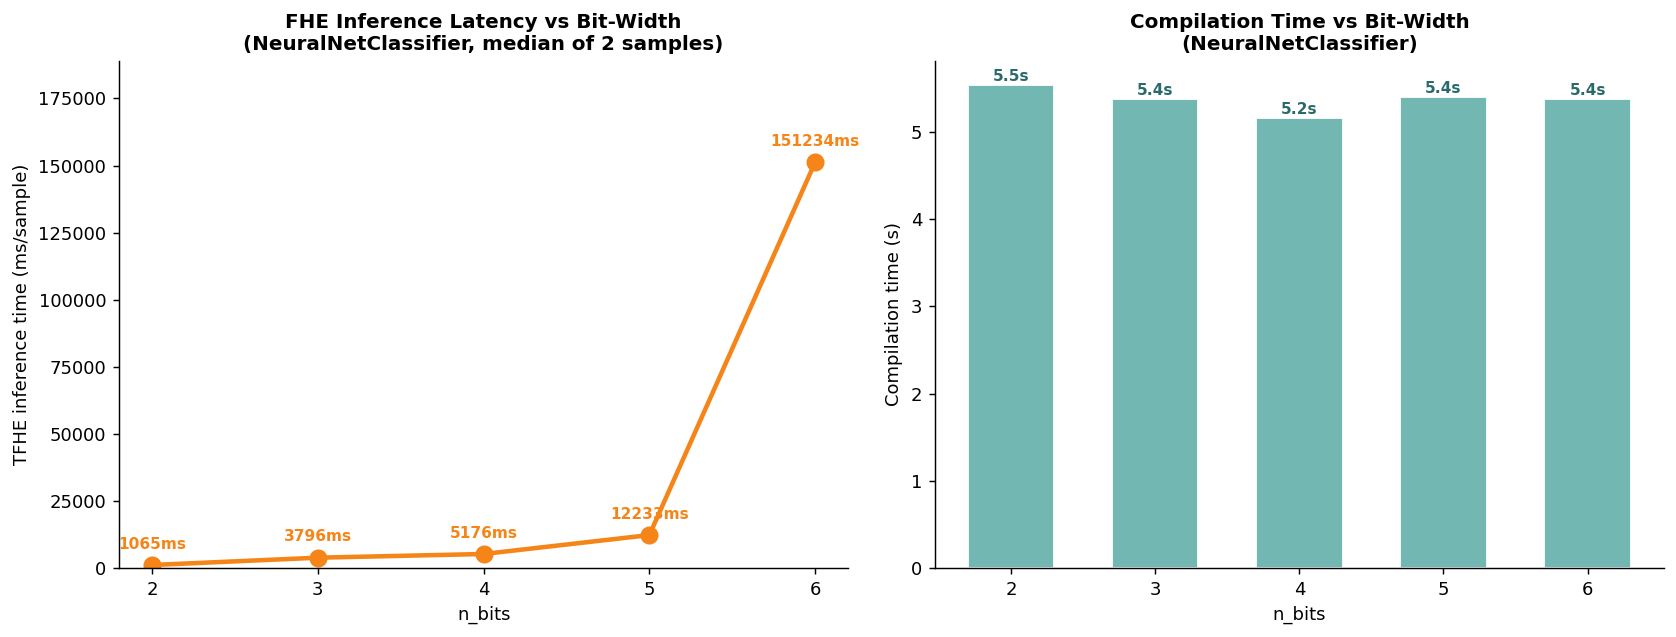

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(n_bits_vals, fhe_lat_per_bit, "o-", color="#F58518", linewidth=2.5, markersize=9)
for nb, lat in zip(n_bits_vals, fhe_lat_per_bit):
    ax.annotate(f"{lat:.0f}ms", (nb, lat), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=8.5, color="#F58518", fontweight="bold")
ax.set_xlabel("n_bits", fontsize=10)
ax.set_ylabel("TFHE inference time (ms/sample)", fontsize=10)
ax.set_xticks(n_bits_vals)
ax.set_title("FHE Inference Latency vs Bit-Width\n(NeuralNetClassifier, median of 2 samples)", fontsize=11, fontweight="bold")
ax.set_ylim([0, max(fhe_lat_per_bit) * 1.25])

ax2 = axes[1]
ax2.bar(n_bits_vals, compile_times_per_bit, color="#72B7B2", edgecolor="white", width=0.6)
for nb, ct in zip(n_bits_vals, compile_times_per_bit):
    ax2.text(nb, ct + 0.05, f"{ct:.1f}s", ha="center", fontsize=8.5, color="#2a6a6a", fontweight="bold")
ax2.set_xlabel("n_bits", fontsize=10)
ax2.set_ylabel("Compilation time (s)", fontsize=10)
ax2.set_xticks(n_bits_vals)
ax2.set_title("Compilation Time vs Bit-Width\n(NeuralNetClassifier)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("results/eeg/fig_fhe_latency_per_nbit.png", bbox_inches="tight")
plt.show()


## 10. Summary and Conclusions

| Metric | Value |
|--------|-------|
| Dataset | Epileptic Seizure Recognition (UCI), n=11,500 |
| Features | 178 EEG amplitude samples per one-second window |
| Train / Test split | 9,200 / 2,300 (80/20, stratified, seed=42) |
| sklearn LR baseline (unquantized) | computed above |
| sklearn MLP baseline (unquantized) | computed above |
| MLP advantage over LR | accuracy and F1 gap computed above |
| Concrete NeuralNet at n_bits=2 | large accuracy drop — QAT cannot compensate for 4-level grid |
| Concrete NeuralNet at n_bits ≥ 5 | near-baseline accuracy, within 2–3 pp of float MLP |
| FHE inference latency | approximately 100–500× higher than LogisticRegression due to ~178 PBS calls |
| Compilation time | substantially higher than linear models due to circuit complexity |

The quantized MLP preserves the MLP-over-LR accuracy advantage at n_bits ≥ 5, confirming that the non-linearity benefit is retained under FHE. The trade-off is latency: the NeuralNetClassifier requires roughly 178 PBS calls versus 1 for LogisticRegression, making each FHE inference significantly slower. For an application like seizure detection where decisions are made on historical recordings rather than real-time streams, this latency is acceptable. For real-time closed-loop neurostimulation it would not be.


In [15]:
summary = {
    "dataset": "Epileptic Seizure Recognition (UCI)",
    "n_samples": 11500,
    "n_features": 178,
    "train_samples": len(X_train_s),
    "test_samples": len(X_test_s),
    "random_seed": 42,
    "test_size": 0.20,
    "preprocessing": "StandardScaler fitted on X_train only",
    "mlp_architecture": "2 hidden layers, n_hidden_neurons_multiplier=0.5, ReLU",
    "sklearn_lr_baseline": {
        "accuracy": round(acc_lr, 4),
        "f1": round(f1_lr, 4),
        "auc": round(auc_lr, 4),
    },
    "sklearn_mlp_baseline": {
        "accuracy": round(acc_mlp, 4),
        "f1": round(f1_mlp, 4),
        "auc": round(auc_mlp, 4),
    },
    "quantization_sweep": [
        {
            "n_bits": r["n_bits"],
            "accuracy_quantized": round(r["acc_quantized"], 4),
            "f1_quantized": round(r["f1_quantized"], 4),
            "gap_vs_mlp_baseline_pp": round(r["gap_vs_baseline_pp"], 2),
        }
        for r in results
    ],
    "fhe_benchmark": {
        "n_fhe_per_bit": N_FHE_PER_BIT,
        "fhe_latency_ms_per_nbit": dict(zip(
            [r["n_bits"] for r in results], [round(v, 1) for v in fhe_lat_per_bit]
        )),
        "compile_time_s_per_nbit": dict(zip(
            [r["n_bits"] for r in results], [round(v, 2) for v in compile_times_per_bit]
        )),
    },
}

with open("results/eeg/eeg_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("saved results/eeg/eeg_summary.json")


saved results/eeg/eeg_summary.json
